# **Практическая работа №10. Разведочный анализ, предобработка данных и обучение моделей классификации**

*(на примере датасета Bank Marketing)*

---

## ****Введение****

**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).

**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.

**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и **экспериментально проверять** гипотезы
- Создавать новые признаки (Feature Engineering)
- **Сравнивать все изученные методы классификации**
- **Выбирать лучшие модели и оптимизировать их гиперпараметры с помощью GridSearchCV**
- **Анализировать влияние комбинаций признаков на качество модели**

---

## ****Часть 1. Настройка окружения****

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [58]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report)

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Отбор признаков
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from itertools import combinations

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## ****Часть 2. Загрузка и первичный осмотр данных****

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### ****Задание 2.1. Загрузите датасет****

In [59]:
# Загрузка датасета Bank Marketing
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

# ВАЖНО: В этом датасете пропуски записаны как "unknown"
# Заменяем их на NaN, чтобы isna() корректно их определял
bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### ****Задание 2.2. Изучите структуру данных****

**1. Выведите размерность датасета:**

In [60]:
bank.shape

(4521, 17)

**2. Отобразите первые 10 строк датасета**

In [61]:
bank.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,NaN,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,NaN,14,may,57,2,-1,0,NaN,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**3. Выведите информацию о типах данных и пропусках**

In [62]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4483 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4334 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    3197 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   816 non-null    str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


**4. Выведите статистику числовых признаков**

In [63]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**5. Выведите названия всех столбцов в виде списка строк**

In [64]:
bank.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### ****Задание 2.3. Ответьте на вопросы****

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---

**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** _______4521_______

**Вопрос 2:** Сколько признаков (столбцов)?

**Ответ:** _______17_______

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?

**Ответ:** _______y_______

**Вопрос 4:** Какие типы данных преобладают — числовые или категориальные?

**Ответ:** _______категориальные_______

---

### ****Описание столбцов датасета Bank Marketing****

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## ****Часть 3. Разведочный анализ данных (EDA)****

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### ****3.1. Анализ целевой переменной (баланс классов)****

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [65]:
# Создаём числовую версию целевой переменной в столбце target
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

In [66]:
# Используйте value_counts()
# ВАШ КОД
bank['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?

**Ответ:** _______521 открыли вклад, а 4000 не открыли_______

---

**Визуализируйте распределения классов графически (постройте столбчатую (barplot) или круговую (pie chart) диаграмму)**

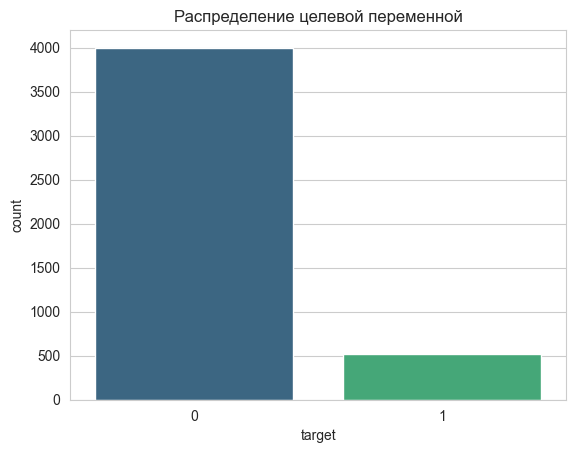

In [67]:
# Используйте sns.countplot() или value_counts().plot(kind='bar')
# ВАШ КОД
sns.countplot(data = bank, x = 'target', palette = 'viridis')
plt.title('Распределение целевой переменной')
plt.show()

---

**Вычислите процент клиентов, открывших вклад**

In [68]:
# ВАШ КОД
print(bank['target'].mean() * 100)

11.523999115239992


**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** _______Классы абсолютно не сбалансированы, сильно преобладает класс не открывших вклад (~88.5) против открывших вклад (~11.5)_______

---

### ****3.2. Анализ пропущенных значений****

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [69]:
# ВАШ КОД
bank.isna().sum

<bound method DataFrame.sum of         age    job  marital  education  default  balance  housing   loan  \
0     False  False    False      False    False    False    False  False   
1     False  False    False      False    False    False    False  False   
2     False  False    False      False    False    False    False  False   
3     False  False    False      False    False    False    False  False   
4     False  False    False      False    False    False    False  False   
...     ...    ...      ...        ...      ...      ...      ...    ...   
4516  False  False    False      False    False    False    False  False   
4517  False  False    False      False    False    False    False  False   
4518  False  False    False      False    False    False    False  False   
4519  False  False    False      False    False    False    False  False   
4520  False  False    False      False    False    False    False  False   

      contact    day  month  duration  campaign  pdays  

**Вычислите процент пропущенных значений в каждом столбце датасета**

In [70]:
# ВАШ КОД
print((bank.isna().mean() * 100).sort_values(ascending = False))

poutcome     81.950896
contact      29.285556
education     4.136253
job           0.840522
age           0.000000
default       0.000000
balance       0.000000
housing       0.000000
loan          0.000000
marital       0.000000
day           0.000000
month         0.000000
campaign      0.000000
duration      0.000000
pdays         0.000000
previous      0.000000
y             0.000000
target        0.000000
dtype: float64


**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

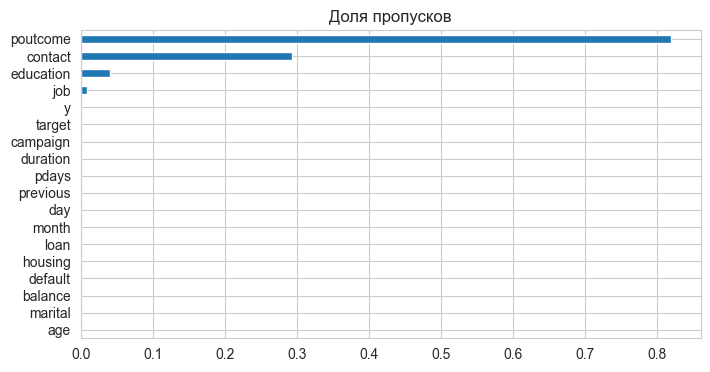

In [71]:
# ВАШ КОД
bank.isna().mean().sort_values().plot(kind = 'barh', figsize = (8, 4), title = 'Доля пропусков')
# sns.barplot(data = bank, x = bank.isna().mean().sort_values())
plt.show()

**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?

**Ответ:** _______Больше всего пропусков в poutcome (~82%) и contact (~29%). Удаление строк затронет 33% данных, что неприемлимо много_______

---

### ****3.3. Анализ числовых признаков****

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).

**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

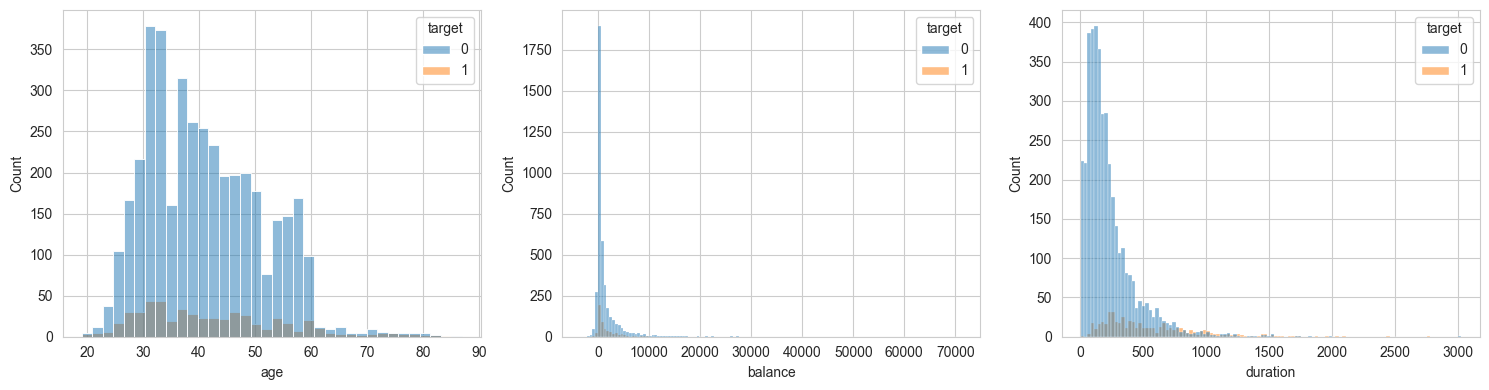

In [72]:
numeric_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    # ВАШ КОД: постройте гистограмму для col на axes[i]
    sns.histplot(data = bank, x = col, hue = 'target', ax = axes[i])

plt.tight_layout()
plt.show()

*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?

**Ответ:** _______Большинство пенсионеров открыли вклад; На большинстве открытых вкладов баланс ~500; Чем длинее звонок, тем выше шанс вклада._______

---

### ****Задание 3.4. Анализ категориальных признаков****

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).

**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

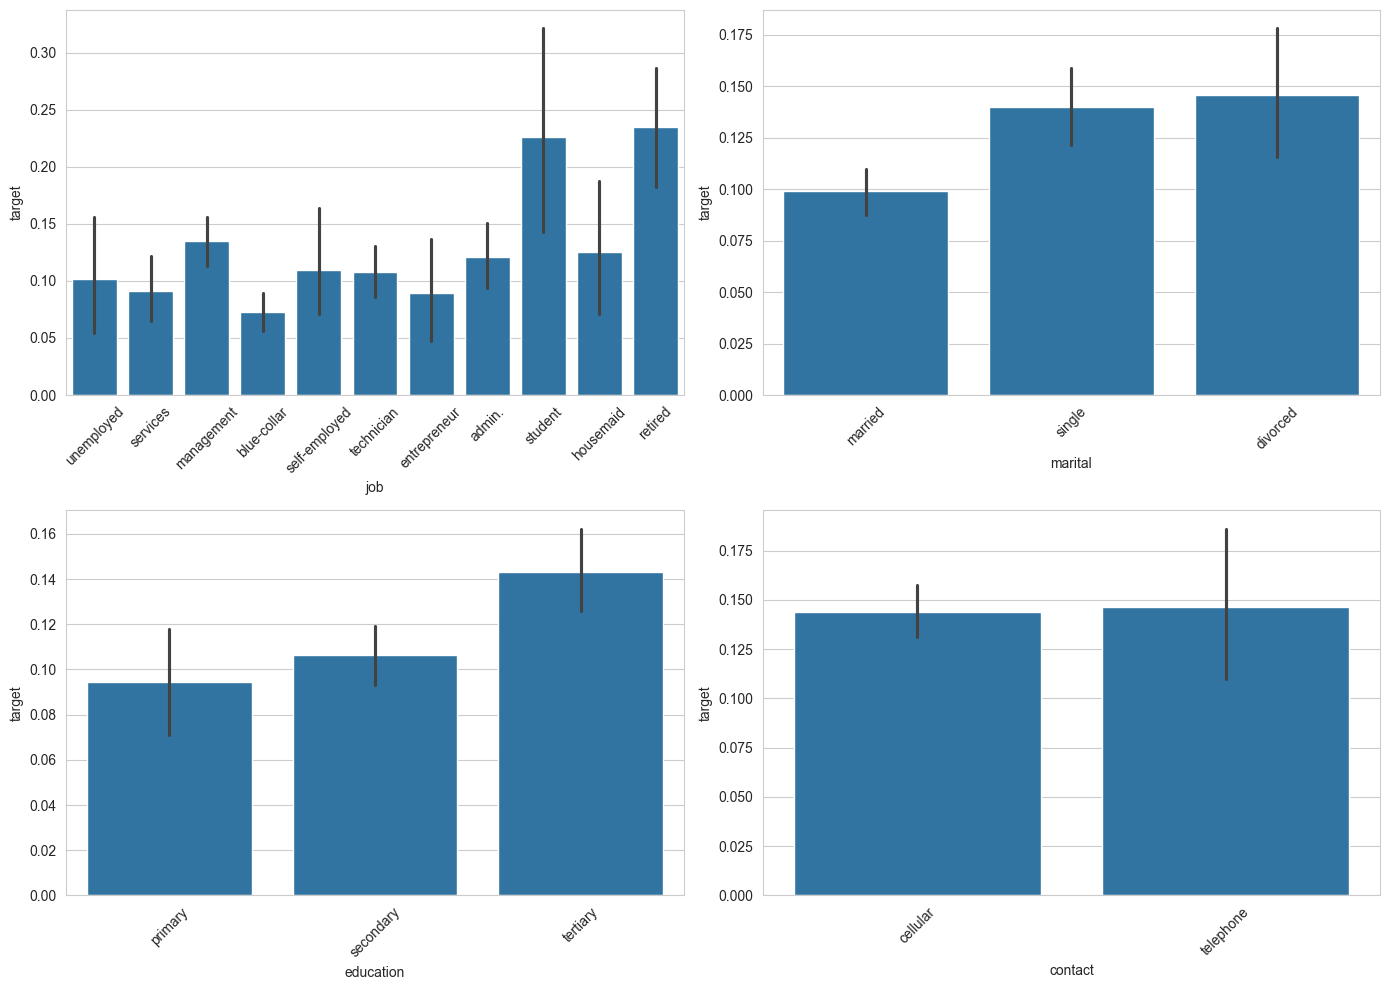

In [73]:
cat_features = ['job', 'marital', 'education', 'contact']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # ВАШ КОД: постройте barplot для col на axes[i]
    # Используйте sns.barplot(data=bank, x=col, y='target', ax=axes[i])
    # Добавьте plt.xticks(rotation=45) для поворота подписей
    sns.barplot(data = bank, x = col, y = 'target', ax = axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

---

**Ответьте на вопросы:**

**Вопрос:** Люди каких профессий чаще открывают депозит?

**Ответ:** _______В порядке убывания: retired (пенсионеры), student, managment_______

**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?

**Ответ:** _______Люди в браке реже открывают вклад, чем одиночки или разведёнки_______

**Вопрос:** Какой тип связи (contact) наиболее эффективен?

**Ответ:** _______По телефону незначительно эффективнее, чем вживую_______

**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?

**Ответ:** _______С вышшим образованием, пенсионеры, разведенные, по телефону (бинго по жизни?)_______

---

### ****Задание 3.5. Анализ связей между признаками (Boxplot)****

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

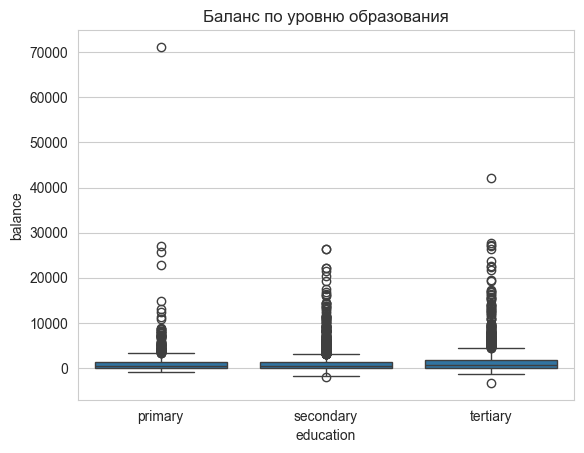

In [74]:
# ВАШ КОД
sns.boxplot(data=bank, x='education', y='balance')
plt.title('Баланс по уровню образования')
plt.show()

**Вопрос:** Различается ли баланс у клиентов с разным образованием?

**Ответ:** _______Немного, у primary и sec. ed. более мене одинаковая медиана и дисперсия, у людей с высшим образованием медиана такая же, но дисперсия больше. На всех графиках много выбросов._______

---

### ****Задание 3.6. Группировка данных****

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [75]:
# ВАШ КОД
bank.groupby('job').agg(avg_balance=('balance', 'mean'), deposit_rate=('target', 'mean')).sort_values('deposit_rate', ascending=False)

,avg_balance,deposit_rate
job,,
retired,2319.191304,0.234783
student,1543.821429,0.226190
management,1766.928793,0.135191
housemaid,2083.803571,0.125000
admin.,1226.736402,0.121339
self-employed,1392.409836,0.109290
technician,1330.996094,0.108073
unemployed,1089.421875,0.101562
services,1103.956835,0.091127


**Вычислите долю открывших депозит по уровню образования**

In [76]:
# ВАШ КОД
bank.groupby('education')['target'].mean().sort_values(ascending=False)

education
tertiary     0.142963
secondary    0.106245
primary      0.094395
Name: target, dtype: float64

---

## ****Часть 4. Формулировка гипотез и план экспериментов****

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).

На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### ****Ваши гипотезы:****

(Дважды нажмите правой кнопкой мыши на ячейку ниже, чтобы вписать свои гипотезы)

| № | Наблюдение из EDA | Гипотеза | Как проверить | Метрика для сравнения |
|---|-------------------|----------|---------------|----------------------|
| 1 | `pdays` = -1 у большинства ("не контактировали") | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 2 | Пропуски в `job`/`education`/`contact` | Факт пропуска информативен | Создать `*_unknown`, сравнить метрики | Accuracy, F1 |
| 3 | `balance` имеет выбросы и отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 4 | `poutcome` отсутствует у большинства данных | Данные могут быть важны | Создать `poutcome_unknown`, сравнить точность | Accuracy, F1 |
| 5 | Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |
| 6 | `previous` = 0 означает "первый контакт" | Создать бинарный признак `first_contact` | Добавить признак, сравнить accuracy | Accuracy, F1 |

**Примеры формулировок (для ориентира):**

| Наблюдение | Гипотеза | Как проверить | Метрика |
|------------|----------|---------------|---------|
| `duration` сильно различается у классов | Признак важен для предсказания | Сравнить accuracy с `duration` и без него | Accuracy, F1 |
| `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| В `job` есть пропуски | Факт пропуска может быть информативен | Создать `job_unknown`, сравнить accuracy | Accuracy, F1 |
| Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |

> 📚 **Подсказка:** Методология проверки гипотез через эксперименты подробно разобрана в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

---

## ****Часть 5. Сравнение методов классификации****

> 📚 **Подсказка:** Различные методы классификации (логистическая регрессия, деревья решений, ансамбли, SVM, KNN) подробно разбирались на занятиях по supervised learning.

### ****5.1. Расширенная функция оценки модели****

> 📚 **Подсказка:** Базовая функция `evaluate_model()` была создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [77]:
def evaluate_model_advanced(model, X, y, model_name="Model"):
    """
    Расширенная оценка модели с множественными метриками.

    Параметры:
    ----------
    model : sklearn estimator
        Модель для обучения и оценки
    X : DataFrame или array
        Признаки
    y : Series или array
        Целевая переменная
    model_name : str
        Название модели для отображения

    Возвращает:
    -----------
    dict : словарь с метриками
    """
    # 1. Разделение данных (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 2. Масштабирование (ВАЖНО: fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Обучение модели
    model.fit(X_train_scaled, y_train)

    # 4. Предсказание
    y_pred = model.predict(X_test_scaled)

    # 5. Вероятности (если модель поддерживает)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = None

    # 6. Расчёт метрик
    results = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc
    }

    return results, y_test, y_pred, y_proba

### ****5.2. Простая функция оценки (для быстрых экспериментов)****

In [78]:
def evaluate_model(X, y):
    """
    Быстрая оценка модели логистической регрессии.
    Возвращает только accuracy.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### ****5.3. Подготовка данных для baseline****

In [79]:
# Выбираем только числовые признаки для baseline
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Подготовьте X и y
X_baseline = bank[numeric_cols]
y_baseline = bank['target']

print(f"Размер X: {X_baseline.shape}")
print(f"Размер y: {y_baseline.shape}")

Размер X: (4521, 7)
Размер y: (4521,)


### ****5.4. Задание: Сравните ВСЕ методы классификации****

**Создайте словарь со всеми моделями:**

In [80]:
# Словарь моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=3),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_jobs=3),
    'Naive Bayes': GaussianNB()
}

**Обучите все модели и соберите результаты:**

In [81]:
# Словарь для хранения всех результатов экспериментов
all_results = {}

# Список для сбора результатов сравнения моделей
comparison_results = []

print("=" * 70)
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)")
print("=" * 70)

for name, model in models.items():
    # ВАШ КОД:
    # 1. Вызовите evaluate_model_advanced() для каждой модели
    # 2. Добавьте результаты в comparison_results
    # 3. Выведите метрики для каждой модели
    results, _, _, _ = evaluate_model_advanced(model, X_baseline, y_baseline, name)
    comparison_results.append(results)

    auc_val = results['roc_auc']
    auc_str = f"{auc_val:.4f}" if auc_val is not None else 'N/A'

    print(f"{name:25} | Acc: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | AUC: {auc_str}")

print("=" * 70)

СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)
Logistic Regression       | Acc: 0.8862 | F1: 0.2370 | AUC: 0.8162
Decision Tree             | Acc: 0.8475 | F1: 0.3365 | AUC: 0.6252
Random Forest             | Acc: 0.8729 | F1: 0.2857 | AUC: 0.8449
Gradient Boosting         | Acc: 0.8807 | F1: 0.3494 | AUC: 0.8491
AdaBoost                  | Acc: 0.8807 | F1: 0.2800 | AUC: 0.8366
SVM                       | Acc: 0.8873 | F1: 0.1639 | AUC: 0.7408
KNN                       | Acc: 0.8917 | F1: 0.3718 | AUC: 0.7192
Naive Bayes               | Acc: 0.8575 | F1: 0.3768 | AUC: 0.8009


### ****5.5. Создайте DataFrame с результатами и визуализируйте****

In [82]:
# Создайте DataFrame из comparison_results
df_comparison = pd.DataFrame.from_records(comparison_results)

# Отсортируйте по F1-score
df_comparison.sort_values('f1', ascending=False)

# Выведите таблицу
df_comparison

,model_name,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
1,Decision Tree,0.847514,0.336538,0.336538,0.336538,0.625198
2,Random Forest,0.872928,0.403509,0.221154,0.285714,0.844947
3,Gradient Boosting,0.880663,0.467742,0.278846,0.349398,0.849101
4,AdaBoost,0.880663,0.456522,0.201923,0.280000,0.836604
5,SVM,0.887293,0.555556,0.096154,0.163934,0.740787
6,KNN,0.891713,0.557692,0.278846,0.371795,0.719167
7,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862


**Постройте визуализацию сравнения моделей:**

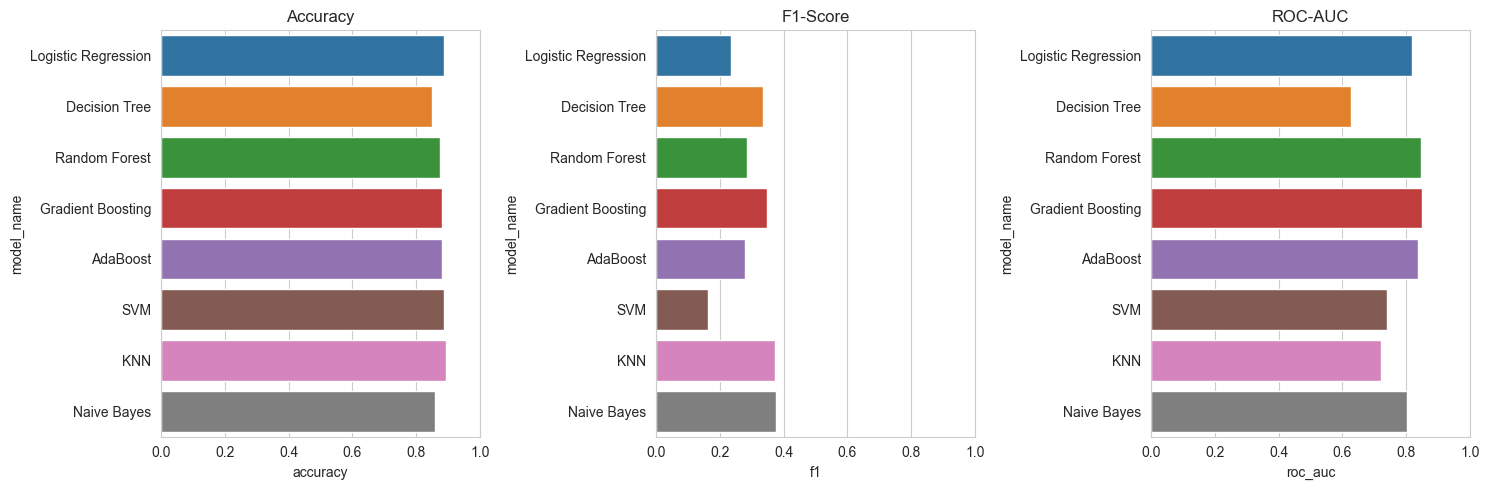

In [83]:
# Постройте barplot для сравнения моделей по разным метрикам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    # ВАШ КОД: постройте barplot на axes[i]
    sns.barplot(data=df_comparison, x=metric, y='model_name', hue='model_name', ax=axes[i], legend=False)
    axes[i].set_title(title)
    axes[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### ****5.6. Ответьте на вопросы****

**Вопрос:** Какие 3 модели показали лучший результат по F1-Score?

**Ответ:** _______Naive Bayes, KNN, Gradient Boosting_______

**Вопрос:** Почему мы ориентируемся на F1-Score, а не на Accuracy? (Подсказка: вспомните баланс классов)

**Ответ:** _______Потому что классы абсолютно не сбалансированы: очень много классов "no" и мало "yes"_______

**Вопрос:** Какая модель показала лучший ROC-AUC? Что это означает?

**Ответ:** _______Лучшая модель: Gradient Boosting. Это означает, что она лучше всех различает классы_______

---

## ****Часть 6. Стратегии обработки пропусков****

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### ****6.1. Стратегия A: Удаление строк с пропусками****

In [84]:
# Посмотрим, сколько данных потеряем
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?

**Ответ:** _______Максимально неприемлимо_______

---

### ****6.2. Стратегия B: Заполнение модой****

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [85]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome']

for col in cat_cols_with_na:
    if df_filled[col].isna().sum() > 0:
        # ВАШ КОД: найдите моду и заполните пропуски
        mode_value = df_filled[col].mode()[0]
        df_filled[col] = df_filled[col].fillna(mode_value)

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")

Пропусков после заполнения: 0


### ****6.3. Стратегия C: Создание признаков из пропусков****

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [86]:
df_fe = bank.copy()

df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)
df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

---

## ****Часть 7. Feature Engineering и отбор признаков****

> 📚 **Подсказка:** Создание новых признаков на основе анализа данных описано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****7.1. Создание новых признаков****

**Создайте следующие признаки на основе гипотез из EDA:**

In [87]:
df_fe = bank.copy()

# 1. Был ли клиент контактирован ранее (pdays != -1)
df_fe['was_contacted'] = (bank['pdays'] != -1).astype(int)

# 2. Положительный баланс
df_fe['has_positive_balance'] = (bank['balance'] > 0).astype(int)

# 3. Признаки из пропусков (ДО заполнения!)
df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)

# Теперь заполняем пропуски
for col in ['job', 'education', 'contact', 'poutcome']:
    if df_fe[col].isna().sum() > 0:
        mode_value = df_fe[col].mode()[0]
        df_fe[col] = df_fe[col].fillna(mode_value)

print("Созданные признаки:")
df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown']].head(10)

Созданные признаки:


,was_contacted,has_positive_balance,job_unknown,education_unknown,contact_unknown
0,0,1,0,0,0
1,1,1,0,0,0
2,1,1,0,0,0
3,0,1,0,0,1
4,0,0,0,0,1
5,1,1,0,0,0
6,1,1,0,0,0
7,0,1,0,0,0
8,0,1,0,0,1
9,1,0,0,0,0


**Добавьте свои признаки на основе ваших гипотез:**

In [88]:
# One-Hot Encoding
df_fe = pd.get_dummies(df_fe, columns=['job', 'marital', 'education', 'contact', 'default', 'housing', 'loan', 'month', 'poutcome'], drop_first=True)

# Poutcome
df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

# Первый контакт с клиентом
df_fe['first_contact'] = (bank['previous'] == 0).astype(int)

print("Созданные признаки:")
df_fe

Созданные признаки:


,age,balance,day,duration,campaign,pdays,previous,y,target,was_contacted,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,first_contact
0,30,1787,19,79,1,-1,0,no,0,0,...,False,False,False,False,True,False,False,False,1,1
1,33,4789,11,220,1,339,4,no,0,1,...,False,False,True,False,False,False,False,False,0,0
2,35,1350,16,185,1,330,1,no,0,1,...,False,False,False,False,False,False,False,False,0,0
3,30,1476,3,199,4,-1,0,no,0,0,...,True,False,False,False,False,False,False,False,1,1
4,59,0,5,226,1,-1,0,no,0,0,...,False,False,True,False,False,False,False,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,-333,30,329,5,-1,0,no,0,0,...,False,False,False,False,False,False,False,False,1,1
4517,57,-3313,9,153,1,-1,0,no,0,0,...,False,False,True,False,False,False,False,False,1,1
4518,57,295,19,151,11,-1,0,no,0,0,...,False,False,False,False,False,False,False,False,1,1
4519,28,1137,6,129,4,211,3,no,0,1,...,False,False,False,False,False,False,True,False,0,0


In [95]:
df_fe.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y', 'target', 'was_contacted', 'has_positive_balance', 'job_unknown',
       'education_unknown', 'contact_unknown', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'contact_telephone',
       'default_yes', 'housing_yes', 'loan_yes', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown', 'first_contact'],
      dtype='str')

### ****7.2. Систематический перебор комбинаций признаков****

> **Цель:** Определить, какие признаки улучшают модель, а какие вносят шум.

**Определите базовый набор признаков и признаки для тестирования:**

In [96]:
# Базовые числовые признаки
base_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']

# Новые созданные признаки для тестирования
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 
                'contact_unknown', 'first_contact', 'poutcome_unknown']

OHE_features = ['housing_yes', 'job_blue-collar', 'job_entrepreneur',
                'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
                'job_services', 'job_student', 'job_technician', 'job_unemployed',
                'loan_yes', 'marital_married', 'marital_single', 'month_aug',
                'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
                'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
                'poutcome_other', 'poutcome_success', 'contact_telephone',
                'default_yes', 'education_secondary', 'education_tertiary']

# Оценим базовую модель
X_base = df_fe[base_features]
y = df_fe['target']

accuracy_base = evaluate_model(X_base, y)
print(f"Базовая модель ({len(base_features)} признаков): Accuracy = {accuracy_base:.4f}")
print(f"Признаки: {base_features}")
print("=" * 60)

Базовая модель (7 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']


**Протестируйте добавление каждого нового признака по отдельности:**

In [ ]:
# Ваш код
accuracies = {}

for i in new_features:
    features = base_features.copy()
    features.append(i)
    X = df_fe[features]
    y = df_fe['target']
    accuracy_fe = evaluate_model(X, y)
    accuracies[i] = accuracy_fe
    print(f"Модель ({len(features)} признаков): Accuracy = {accuracy_fe:.4f}")
    print(f"Признаки: {features}")
    print("=" * 60)

features_fe = base_features.copy()
features_fe.append(OHE_features)
X_fe = df_fe[features]
y_fe = df_fe['target']
accuracy_fe = evaluate_model(X_fe, y_fe)
accuracies['One-Hot'] = accuracy_fe
print(f"Модель ({len(features_fe)} признаков): Accuracy = {accuracy_fe:.4f}")
print(f"Признаки: {features_fe}")
print("=" * 60)

pd.DataFrame.from_dict(accuracies, orient='index')

Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'was_contacted']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'has_positive_balance']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'job_unknown']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'education_unknown']
Модель (8 признаков): Accuracy = 0.8818
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'contact_unknown']
Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'first_contact']
Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'poutcome_unknown']
Модель (8 признаков)

,0
was_contacted,0.891713
has_positive_balance,0.886188
job_unknown,0.886188
education_unknown,0.886188
contact_unknown,0.881768
first_contact,0.891713
poutcome_unknown,0.891713
One-Hot,0.891713


**Вопрос:** Какие признаки улучшили модель? Какие ухудшили (внесли шум)?

**Ответ:** _______Признаки, которые улучшили модель: `was_contacted`, `first_contact`, `poutcome_unknown`, `OHE`. Признак, который ухудшил модель: `contact_unknown`. Признаки, не давшие никакого результата: `has_positive_balance`,`job_unknown`,`education_unknown`._______

### ****7.3. Анализ важности признаков с помощью Random Forest****

ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)
             feature  importance
            duration    0.348305
             balance    0.160393
                 age    0.152472
                 day    0.131554
               pdays    0.068536
            campaign    0.058062
            previous    0.028170
     contact_unknown    0.016204
   education_unknown    0.008382
has_positive_balance    0.008287
       first_contact    0.005711
    poutcome_unknown    0.005675
       was_contacted    0.004945
         job_unknown    0.003302


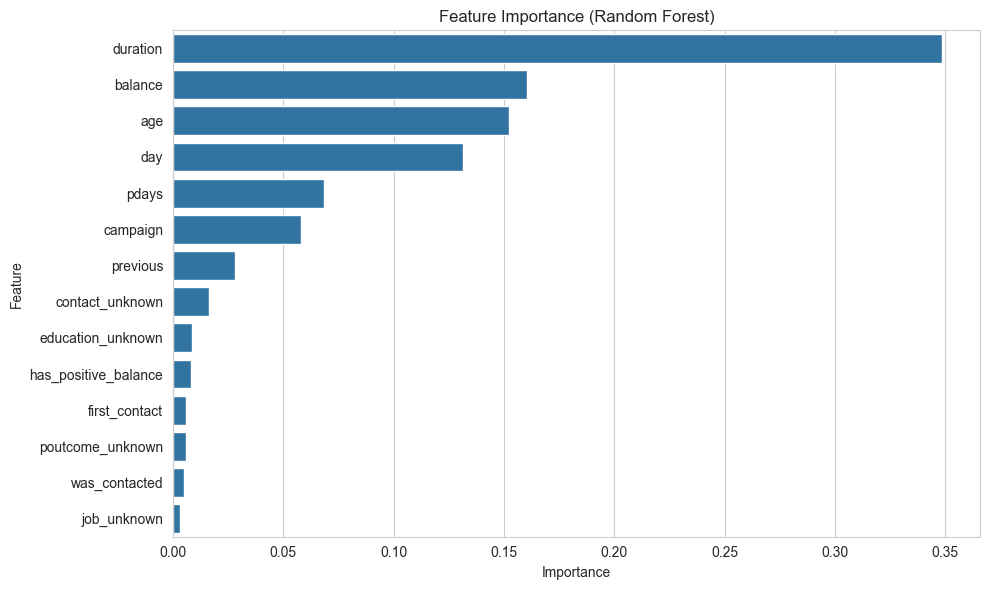

In [98]:
# Соберём все признаки
all_numeric_features = base_features + new_features
X_all = df_fe[all_numeric_features]

# Обучим Random Forest и посмотрим важность признаков
from sklearn.ensemble import RandomForestClassifier

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Обучение
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)")
print("=" * 40)
print(importance_df.to_string(index=False))
print("=" * 40)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### ****7.4. Рекурсивное исключение признаков (RFE)****

> 📚 **Подсказка:** [RFE](https://habr.com/ru/companies/otus/articles/528676/) автоматически отбирает наиболее важные признаки, последовательно удаляя наименее значимые.

In [99]:
from sklearn.feature_selection import RFE

# Применяем RFE для отбора лучших признаков
selector = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=7,  # Отберём 7 лучших признаков
    step=1
)

selector.fit(X_scaled, y)

# Какие признаки отобраны?
selected_features = [f for f, s in zip(all_numeric_features, selector.support_) if s]
rejected_features = [f for f, s in zip(all_numeric_features, selector.support_) if not s]

print("РЕЗУЛЬТАТЫ RFE")
print("=" * 40)
print(f"Отобранные признаки ({len(selected_features)}): {selected_features}")
print(f"Отвергнутые признаки ({len(rejected_features)}): {rejected_features}")
print("=" * 40)

# Сравним accuracy
X_selected = df_fe[selected_features]
accuracy_selected = evaluate_model(X_selected, y)
accuracy_all = evaluate_model(X_all, y)

print(f"\nAccuracy (все {len(all_numeric_features)} признаков): {accuracy_all:.4f}")
print(f"Accuracy (отобранные {len(selected_features)} признаков): {accuracy_selected:.4f}")
print(f"Разница: {accuracy_selected - accuracy_all:+.4f}")

РЕЗУЛЬТАТЫ RFE
Отобранные признаки (7): ['duration', 'campaign', 'pdays', 'was_contacted', 'contact_unknown', 'first_contact', 'poutcome_unknown']
Отвергнутые признаки (7): ['age', 'balance', 'previous', 'day', 'has_positive_balance', 'job_unknown', 'education_unknown']

Accuracy (все 14 признаков): 0.8862
Accuracy (отобранные 7 признаков): 0.8895
Разница: +0.0033


**Вопрос:** Помог ли отбор признаков улучшить модель? Какие признаки оказались лишними?

**Ответ:** _______Совсем чуть-чуть помог, лишними оказалось большинство, кроме `duration`, `contact_unknown`, `month_aug`, `month_jul`, `month_may`, `month_nov`, `poutcome_success`_______

---

## ****Часть 8. Кодирование категориальных признаков****

> 📚 **Подсказка:** One-Hot Encoding для категориальных признаков рассматривался в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### 8.1 было проделано ранее

### ****8.1. Примените One-Hot Encoding****

In [ ]:
# Определяем категориальные столбцы для кодирования
#cat_cols_to_encode = ['job', 'marital', 'education', 'default', 'housing',
#                       'loan', 'contact', 'month', 'poutcome']

# Применяем One-Hot Encoding
#df_encoded = pd.get_dummies(df_fe, columns=cat_cols_to_encode, drop_first=True)

#print(f"Было признаков: {df_fe.shape[1]}")
#print(f"Стало признаков: {df_encoded.shape[1]}")

### ****8.2. Подготовьте финальный набор признаков****

In [100]:
# Удаляем целевые переменные и служебные столбцы
cols_to_drop = ['y', 'target']
X_final = df_fe.drop(columns=cols_to_drop)
y_final = df_fe['target']

print(f"Финальный размер X: {X_final.shape}")
print(f"Количество признаков: {X_final.shape[1]}")

Финальный размер X: (4521, 45)
Количество признаков: 45


### ****8.3. Сравните модели на расширенном наборе признаков****

In [109]:
print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ")
print("=" * 70)

comparison_results_extended = []

for name, model in models.items():
    # Создаём новый экземпляр модели
    if name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Decision Tree':
        model = DecisionTreeClassifier(random_state=42)
    elif name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(random_state=42)
    elif name == 'SVM':
        model = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        model = KNeighborsClassifier()
    elif name == 'Naive Bayes':
        model = GaussianNB()

    results, _, _, _ = evaluate_model_advanced(model, X_final, y_final, name)
    comparison_results_extended.append(results)
    
    auc_val = results['roc_auc']
    auc_str = f"{auc_val:.4f}" if auc_val is not None else 'N/A'
    
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {auc_str}")

print("=" * 70)

# Создайте DataFrame и отсортируйте по F1
df_comparison_extended = pd.DataFrame(comparison_results_extended)
df_comparison_extended = df_comparison_extended.sort_values('f1', ascending=False)
print("\nРАНЖИРОВАНИЕ ПО F1-SCORE:")
print(df_comparison_extended[['model_name', 'accuracy', 'f1', 'roc_auc']].to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ
Logistic Regression       | Accuracy: 0.8917 | F1: 0.3951 | ROC-AUC: 0.8918
Decision Tree             | Accuracy: 0.8564 | F1: 0.4144 | ROC-AUC: 0.6762
Random Forest             | Accuracy: 0.8862 | F1: 0.3179 | ROC-AUC: 0.8929
Gradient Boosting         | Accuracy: 0.8895 | F1: 0.4382 | ROC-AUC: 0.8993
AdaBoost                  | Accuracy: 0.8906 | F1: 0.3774 | ROC-AUC: 0.8770
SVM                       | Accuracy: 0.8840 | F1: 0.2857 | ROC-AUC: 0.8755
KNN                       | Accuracy: 0.8884 | F1: 0.3129 | ROC-AUC: 0.7552
Naive Bayes               | Accuracy: 0.8177 | F1: 0.3678 | ROC-AUC: 0.7840

РАНЖИРОВАНИЕ ПО F1-SCORE:
         model_name  accuracy       f1  roc_auc
  Gradient Boosting  0.889503 0.438202 0.899267
      Decision Tree  0.856354 0.414414 0.676210
Logistic Regression  0.891713 0.395062 0.891806
           AdaBoost  0.890608 0.377358 0.877023
        Naive Bayes  0.817680 0.367816 0.783972
      Random Forest  0.8861

---

## ****Часть 9. Выбор топ-3 моделей****

### ****9.1. Определите топ-3 модели по F1-Score****

In [105]:
# Выберите топ-3 модели из df_comparison_extended
top_3_models = df_comparison_extended.head(3)['model_name'].tolist()

print("ТОП-3 МОДЕЛИ ПО F1-SCORE:")
print("=" * 40)
for i, model_name in enumerate(top_3_models, 1):
    row = df_comparison_extended[df_comparison_extended['model_name'] == model_name].iloc[0]
    print(f"{i}. {model_name}: F1 = {row['f1']:.4f}, ROC-AUC = {row['roc_auc']:.4f}")
print("=" * 40)

ТОП-3 МОДЕЛИ ПО F1-SCORE:
1. Gradient Boosting: F1 = 0.4382, ROC-AUC = 0.8993
2. Decision Tree: F1 = 0.4144, ROC-AUC = 0.6762
3. Logistic Regression: F1 = 0.3951, ROC-AUC = 0.8918


### ****9.2. Постройте ROC-кривые для топ-3 моделей****

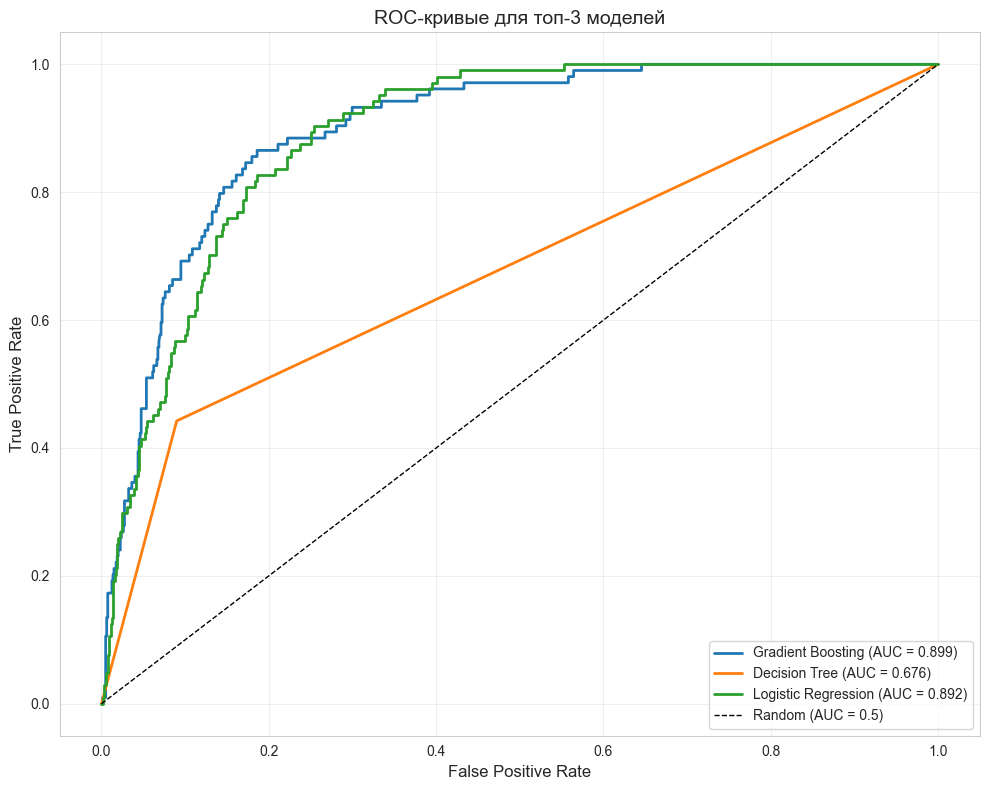

In [106]:
from sklearn.metrics import roc_curve, auc

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Словарь для топ-3 моделей
top_3_model_objects = {}
for name in top_3_models:
    if name == 'Logistic Regression':
        top_3_model_objects[name] = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Random Forest':
        top_3_model_objects[name] = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Gradient Boosting':
        top_3_model_objects[name] = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        top_3_model_objects[name] = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    elif name == 'Decision Tree':
        top_3_model_objects[name] = DecisionTreeClassifier(random_state=42)
    elif name == 'SVM':
        top_3_model_objects[name] = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        top_3_model_objects[name] = KNeighborsClassifier()
    elif name == 'Naive Bayes':
        top_3_model_objects[name] = GaussianNB()

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model in top_3_model_objects.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для топ-3 моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ****9.3. Постройте Confusion Matrix для топ-3 моделей****

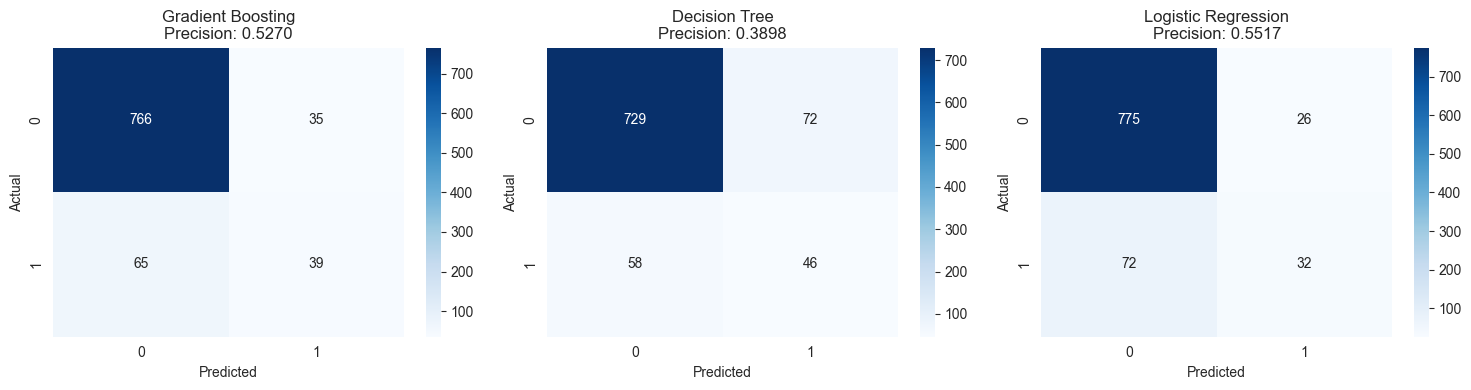

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(top_3_model_objects.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    precision = precision_score(y_test, y_pred, pos_label=1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}\nPrecision: {precision:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()



**Вопрос:** Какая модель лучше всего находит положительный класс (клиентов, которые откроют вклад)?

**Ответ:** _______Desicion Tree лучше всего находит положительный класс, хотя её точность хуже 2-ух других._______

---

## ****Часть 10. Оптимизация гиперпараметров с GridSearchCV****

> 📚 **Подсказка:** GridSearchCV перебирает все комбинации гиперпараметров и выбирает лучшую с помощью кросс-валидации.

### ****10.1. Определите сетки гиперпараметров для топ-3 моделей****

In [119]:
# Сетки гиперпараметров для разных моделей
max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=7)]
max_depth.append(None)
gb_params = {'learning_rate': [float(i) for i in np.linspace(start=0.01, stop=3.0, num=7)],
             'max_features': ['log2', 'auto', None],
             'min_samples_leaf': [int(i) for i in np.linspace(start=1, stop=50, num=7)],
             'max_depth': max_depth}
dt_params = {'min_samples_split': [int(i) for i in np.linspace(start=2, stop=100, num=15)],
             'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=15)],
             'max_depth': max_depth}
lr_params = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
             'C': [float(i) for i in np.linspace(start=0.01, stop=3.0, num=7)],
             'class_weight': ['balanced', None],
             'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

### ****10.2. Запустите GridSearchCV для каждой модели из топ-3****

In [ ]:
# Результаты тюнинга (11 минут)
from sklearn.model_selection import GridSearchCV
gs_gb = GridSearchCV(estimator=top_3_model_objects['Gradient Boosting'], param_grid=gb_params, cv=5, n_jobs=4, verbose=1)
gs_gb.fit(X_train_scaled, y_train)

gb_best = gs_gb.best_estimator_

Fitting 5 folds for each of 1176 candidates, totalling 5880 fits


In [ ]:
# 11 секунд
gs_dt = GridSearchCV(estimator=top_3_model_objects['Decision Tree'], param_grid=dt_params, cv=5, n_jobs=4, verbose=1)
gs_dt.fit(X_train_scaled, y_train)
dt_best = gs_dt.best_estimator_

Fitting 5 folds for each of 1800 candidates, totalling 9000 fits


In [120]:
# 
gs_lr = GridSearchCV(estimator=top_3_model_objects['Logistic Regression'], param_grid=lr_params, cv=5, n_jobs=4, verbose=1)
gs_lr.fit(X_train_scaled, y_train)
lr_best = gs_lr.best_estimator_

Fitting 5 folds for each of 280 candidates, totalling 1400 fits


In [121]:
display(gb_best)
display(dt_best)
display(lr_best)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.5083333333333333
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",9
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",40
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",16
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.5050000000000001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [122]:
results = pd.DataFrame(gs_gb.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

                  score_range
learning_rate        0.216478
max_depth            0.095267
min_samples_leaf     0.073323
max_features         0.000000


In [123]:
results = pd.DataFrame(gs_dt.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

                   score_range
max_leaf_nodes        0.011758
max_depth             0.009679
min_samples_split     0.007227


In [124]:
results = pd.DataFrame(gs_lr.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

              score_range
C                0.002973
solver           0.001798
penalty          0.001768
class_weight     0.000000


In [125]:
best_models = {'Gradient Boosting': gb_best, 'Decision Tree': dt_best, 'Logistic Regression': lr_best}
tuning_results = {}
for i, (name, model) in enumerate(best_models.items()):
  res1 = {}
  res1['best_estimator'] = best_models[name]
  res1['f1'] = f1_score(y_test, model.predict(X_test_scaled))
  res1['accuracy'] = accuracy_score(y_test, model.predict(X_test_scaled))
  display(res1)
  tuning_results[name] = res1

{'best_estimator': GradientBoostingClassifier(learning_rate=0.5083333333333333, max_depth=40,
                            max_features='log2', min_samples_leaf=9,
                            random_state=42),
 'f1': 0.4,
 'accuracy': 0.8906077348066298}

{'best_estimator': DecisionTreeClassifier(max_depth=14, max_leaf_nodes=16, min_samples_split=100,
                        random_state=42),
 'f1': 0.5539906103286385,
 'accuracy': 0.8950276243093923}

{'best_estimator': LogisticRegression(C=1.5050000000000001, max_iter=1000, penalty='l1',
                    random_state=42, solver='liblinear'),
 'f1': 0.39751552795031053,
 'accuracy': 0.8928176795580111}

### ****10.3. Сравните результаты ДО и ПОСЛЕ тюнинга****

In [135]:
print("=" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА")
print("=" * 70)

comparison_tuning = []

for name in top_3_models:
    # Результаты до тюнинга
    before = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]

    # Результаты после тюнинга
    after = tuning_results.get(name, {})

    if after:
        comparison_tuning.append({
            'Model': name,
            'F1 (до)': before['f1'],
            'F1 (после)': after['f1'],
            'Δ F1': after['f1'] - before['f1'],
            'Accuracy (до)': before['accuracy'],
            'Accuracy (после)': after['accuracy'],
            'Δ Accuracy': after['accuracy'] - before['accuracy']
        })

df_tuning_comparison = pd.DataFrame(comparison_tuning)
print(df_tuning_comparison.to_string(index=False))
print("=" * 70)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА
              Model  F1 (до)  F1 (после)      Δ F1  Accuracy (до)  Accuracy (после)  Δ Accuracy
  Gradient Boosting 0.438202    0.400000 -0.038202       0.889503          0.890608    0.001105
      Decision Tree 0.414414    0.553991  0.139576       0.856354          0.895028    0.038674
Logistic Regression 0.395062    0.397516  0.002454       0.891713          0.892818    0.001105


**Вопрос:** Для какой модели тюнинг дал наибольшее улучшение?

**Ответ:** _______В данном случае - Decision Tree, с улучшением в ~0.14 по F1 Score (итог - 0.554 F1)_______

**Вопрос:** Какие гиперпараметры оказали наибольшее влияние на качество?

**Ответ:** 
_______Gradient Boosting - гиперпараметр `learning_rate`, Decision Tree - `max_leaf_nodes`, Logistic Regression - `C`______

## ****Часть 11. Финальное сравнение и выводы****

### ****11.1. Постройте итоговую таблицу всех экспериментов****

In [139]:
# Соберите все эксперименты в одну таблицу
final_summary = []

# Baseline (только числовые признаки)
baseline_results = df_comparison.iloc[0]  # Лучшая модель на baseline
final_summary.append({
    'Эксперимент': 'Baseline (числовые признаки)',
    'Модель': baseline_results['model_name'],
    'Кол-во признаков': len(numeric_cols),
    'F1-Score': baseline_results['f1'],
    'Accuracy': baseline_results['accuracy']
})

# После Feature Engineering
extended_results = df_comparison_extended.iloc[0]
final_summary.append({
    'Эксперимент': 'Feature Engineering + One-Hot',
    'Модель': extended_results['model_name'],
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': extended_results['f1'],
    'Accuracy': extended_results['accuracy']
})

# После тюнинга (лучшая модель)
best_tuned = max(tuning_results.items(), key=lambda x: x[1]['f1'])
final_summary.append({
    'Эксперимент': 'После GridSearchCV',
    'Модель': f"{best_tuned[0]} (tuned)",
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': best_tuned[1]['f1'],
    'Accuracy': best_tuned[1]['accuracy']
})

df_final_summary = pd.DataFrame(final_summary)
print("=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("=" * 80)
print(df_final_summary.to_string(index=False))
print("=" * 80)

ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
                  Эксперимент                Модель  Кол-во признаков  F1-Score  Accuracy
 Baseline (числовые признаки)   Logistic Regression                 7  0.237037  0.886188
Feature Engineering + One-Hot     Gradient Boosting                45  0.438202  0.889503
           После GridSearchCV Decision Tree (tuned)                45  0.553991  0.895028


### ****11.2. Визуализируйте прогресс улучшения модели****

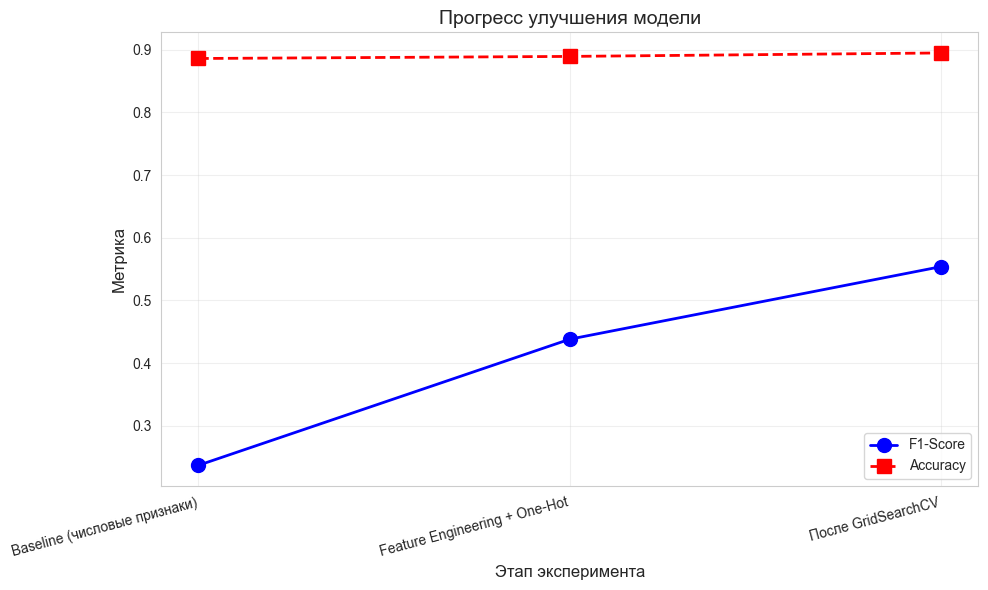


ОБЩИЙ ПРИРОСТ:
F1-Score: 0.2370 → 0.5540 (+0.3170)
Accuracy: 0.8862 → 0.8950 (+0.0088)


In [140]:
# График прогресса
plt.figure(figsize=(10, 6))

x = range(len(df_final_summary))
plt.plot(x, df_final_summary['F1-Score'], 'bo-', markersize=10, linewidth=2, label='F1-Score')
plt.plot(x, df_final_summary['Accuracy'], 'rs--', markersize=10, linewidth=2, label='Accuracy')

plt.xticks(x, df_final_summary['Эксперимент'], rotation=15, ha='right')
plt.xlabel('Этап эксперимента', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Прогресс улучшения модели', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Прирост
print(f"\nОБЩИЙ ПРИРОСТ:")
print(f"F1-Score: {df_final_summary.iloc[0]['F1-Score']:.4f} → {df_final_summary.iloc[-1]['F1-Score']:.4f} ({df_final_summary.iloc[-1]['F1-Score'] - df_final_summary.iloc[0]['F1-Score']:+.4f})")
print(f"Accuracy: {df_final_summary.iloc[0]['Accuracy']:.4f} → {df_final_summary.iloc[-1]['Accuracy']:.4f} ({df_final_summary.iloc[-1]['Accuracy'] - df_final_summary.iloc[0]['Accuracy']:+.4f})")

### ****11.3. Ответьте на итоговые вопросы****

---

**Вопрос 1:** Какая модель показала лучший финальный результат и почему, по вашему мнению?

**Ответ:** _______Decision Tree_______

---

**Вопрос 2:** Какие признаки оказались шумовыми (ухудшали модель)?

**Ответ:** _______большинство из `month` (кроме oct, jun, mar), `day`, `education`, `job`, `loan`, `campaign`, `contact` (кроме contact_unknown), `marital` (проще, в общем, перечислить те, которые были полезными)_______

---

**Вопрос 3:** Насколько Feature Engineering улучшил результат по сравнению с baseline?

**Ответ:** _______Намного, в целых ~0.3 по F1 Score._______

---

**Вопрос 4:** Насколько GridSearchCV улучшил результат? Стоило ли это затраченного времени?

**Ответ:** _______GridSearchCV улучшил результат на ~0.14. В принципе, учитывая, что эта модель подбиралась быстрее всех (за ~3 минут), оно того явно стоило._______

---

**Вопрос 5:** Какие гиперпараметры оказали наибольшее влияние на качество лучшей модели?

**Ответ:** _______`max_leaf_nodes`_______

---

**Вопрос 6:** Какие подтвердились из ваших гипотез, сформулированных в Части 4? Какие не подтвердились?

**Ответ:** _______Всё, кроме отрицательных значений в balance (и частично в OHE)_______

---

**Вопрос 7:** Что бы вы попробовали ещё для улучшения модели, если бы было больше времени?

**Ответ:** _______Устроить ещё больший подбор гиперпараметров или придумать ещё более интересные гипотезы_______

---

## ****Бонус: Сохранение лучшей модели****

In [141]:
import joblib

# Сохраняем лучшую модель
best_model_name = best_tuned[0]
best_model = tuning_results[best_model_name]['best_estimator']

joblib.dump(best_model, 'best_bank_marketing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_bank_marketing_model.pkl'")
print(f"Scaler сохранён в 'scaler.pkl'")

Лучшая модель (Decision Tree) сохранена в 'best_bank_marketing_model.pkl'
Scaler сохранён в 'scaler.pkl'
